In [2]:
import pickle

with open('../logs/combined_f_combined/resnet18_log_data.pkl', 'rb') as f:
    result = pickle.load(f)

In [3]:
val_losses = result['vl']

In [4]:
new_val_losses = [[], []]
original_len = len(val_losses)
for i in range (0, len(new_val_losses)):
    val_losses[i + original_len] = new_val_losses[i]

In [5]:
with open('../logs/combined_f_combined/activations/30/f/border_cams.pkl', 'rb') as f:
    cams = pickle.load(f)

In [6]:
len(cams)

61760

In [7]:
import numpy as np

mean_cam_per_img = np.array([np.mean(item) for item in cams])

/Users/luoyifan/opt/anaconda3/envs/torch-arm64/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/luoyifan/opt/anaconda3/envs/torch-arm64/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [8]:
len(mean_cam_per_img)

61760

In [9]:
mean_cam_per_img = mean_cam_per_img[~np.isnan(mean_cam_per_img)]

In [10]:
cam_data_per_view = [mean_cam_per_img, mean_cam_per_img, mean_cam_per_img]

In [11]:
cam_data_per_view

[array([0.670723  , 0.5561392 , 0.37340933, ..., 0.8011445 , 0.40987104,
        0.74050045], dtype=float32),
 array([0.670723  , 0.5561392 , 0.37340933, ..., 0.8011445 , 0.40987104,
        0.74050045], dtype=float32),
 array([0.670723  , 0.5561392 , 0.37340933, ..., 0.8011445 , 0.40987104,
        0.74050045], dtype=float32)]

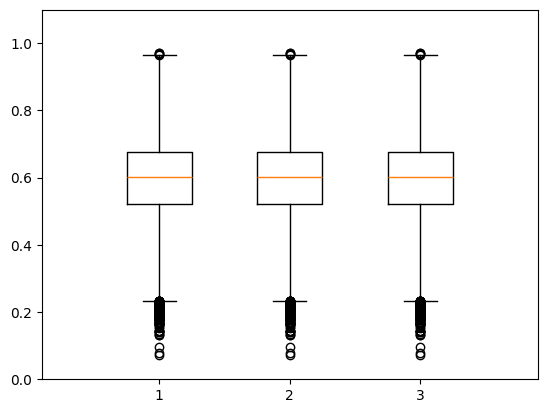

In [27]:
from matplotlib import pyplot as plt

plt.boxplot(cam_data_per_view, tick_labels=['1', '2', '3'], vert=True, whis=1.9, widths = 0.5)
plt.xlim([0.1, 3+0.9])
plt.ylim([0, 1.1])
plt.show()

In [45]:
print(sum(np.isnan(mean_cam_per_img)))

86


In [17]:
others = ['no', 'yes']
suffix = [''].extend(others)

In [18]:
suffix

In [19]:
type(suffix)

NoneType